# Online Retail Analysis - Exploratory Data Analysis (EDA)

This notebook explores the cleaned Online Retail dataset to identify key business insights.

The analysis focuses on:
- Dataset overview
- Sales performance
- Customer and order metrics
- Monthly revenue trends
- Revenue by country
- Product performance

In [10]:
# Import required libraries for data analysis and visualization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Loading the Cleaned Dataset

The cleaned dataset generated during the data preparation stage is loaded for exploratory data analysis.

The `InvoiceNo` column is imported as a string to preserve its original format.

In [11]:
# Load the cleaned dataset

df = pd.read_csv(
    "data/cleaned/online_retail_cleaned.csv",
    dtype={"InvoiceNo": str}
)

## 2. Dataset Inspection

The dataset is inspected to verify its structure, data types, and overall contents before beginning the analysis.

In [12]:
# Display the data types of all columns

df.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
Revenue        float64
dtype: object

### Result

The dataset was loaded successfully with the expected column structure.

The `InvoiceDate` column is currently stored as an object and will be converted to a datetime format later to support time-based analysis.

In [17]:
# Display the first five records of the cleaned dataset

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


### Dataset Preview

The first few records are displayed to verify that the cleaned dataset has been loaded correctly.

The dataset includes transaction details, product information, customer identifiers, sales values, and the Revenue feature created during the data cleaning stage.

In [20]:
# Check the dimensions of the cleaned dataset

df.shape

(524878, 9)

### Result

The cleaned dataset contains **524,878 transaction records** and **9 columns**.

The dataset is now ready for exploratory analysis, providing sufficient information to evaluate sales performance, customer activity, and product trends.

## 3. Key Performance Indicators (KPIs)

Key business metrics are calculated to provide a high-level overview of the dataset before performing detailed analysis.

The following KPIs are computed:

- Total Revenue
- Total Orders
- Total Customers
- Total Products

In [31]:
# Calculate key business metrics from the cleaned dataset

total_revenue = df["Revenue"].sum()

total_orders = df["InvoiceNo"].nunique()

total_customers = df["CustomerID"].nunique()

total_products = df["StockCode"].nunique()


# Display the calculated KPIs

print("Total Revenue:", total_revenue)
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Total Products:", total_products)

Total Revenue: 10642110.803999998
Total Orders: 19960
Total Customers: 4338
Total Products: 3922


### Result

The key business metrics of the cleaned dataset are:

- **Total Revenue:** £10,642,110.80
- **Total Orders:** 19,960
- **Total Customers:** 4,338
- **Total Products:** 3,922

These KPIs provide an overall snapshot of business performance and establish a baseline for the detailed analyses that follow.

## 4. Average Order Value

Average Order Value (AOV) measures the average revenue generated per order.

It is calculated by dividing the total revenue by the total number of unique orders.

In [37]:
# Calculate the average revenue generated per order

average_order_value = total_revenue / total_orders


# Display the Average Order Value

print("Average Order Value: £", round(average_order_value, 2))

Average Order Value: £ 533.17


### Business Insight

The Average Order Value (AOV) is **£533.17**.

This indicates that, on average, each completed order generated approximately **£533** in revenue, providing a useful measure of customer spending per transaction.

## 5. Monthly Revenue Analysis

Monthly revenue is analysed to identify sales trends and seasonal patterns throughout the available time period.

The `InvoiceDate` column is first converted to a datetime format, and a new `Month` feature is created to support monthly aggregation.

In [43]:
# Convert the InvoiceDate column to datetime format

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])


# Create a new Month column for monthly trend analysis

df["Month"] = df["InvoiceDate"].dt.to_period("M")

In [45]:
# Calculate total revenue generated in each month

monthly_revenue = df.groupby("Month")["Revenue"].sum()

monthly_revenue

Month
2010-12     821452.730
2011-01     689811.610
2011-02     522545.560
2011-03     716215.260
2011-04     536968.491
2011-05     769296.610
2011-06     760547.010
2011-07     718076.121
2011-08     757841.380
2011-09    1056435.192
2011-10    1151263.730
2011-11    1503866.780
2011-12     637790.330
Freq: M, Name: Revenue, dtype: float64

### Result

Monthly revenue has been aggregated by transaction month, providing a time series of total sales revenue.


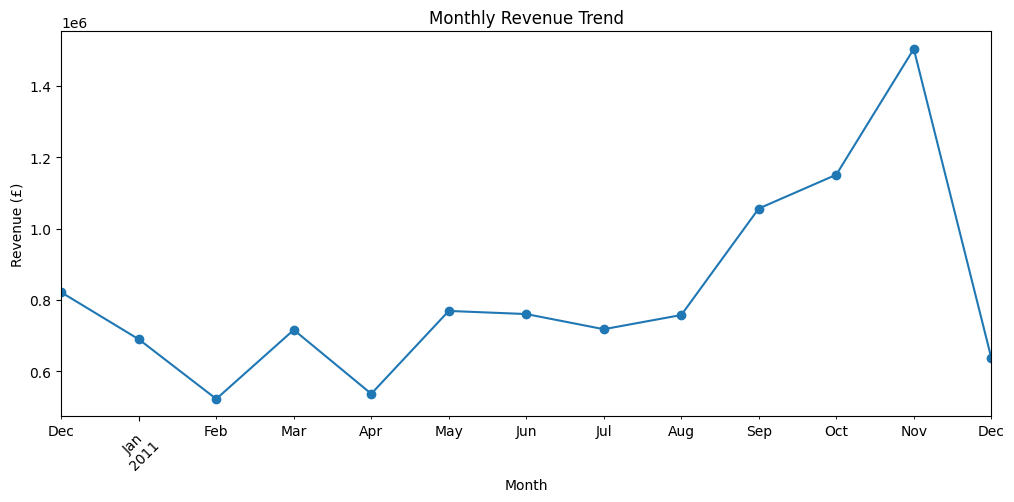

In [48]:
# Visualize the monthly revenue trend

plt.figure(figsize=(12,5))

monthly_revenue.plot(
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)

plt.show()

### Result

Monthly revenue was successfully aggregated, providing a month-by-month summary of sales performance.

This aggregation enables the identification of revenue trends and seasonal variations over the analysis period.

In [31]:
# Visualize the monthly revenue trend

plt.figure(figsize=(12,5))

monthly_revenue.plot(
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)

plt.show()

### Business Insight

Monthly revenue remained relatively stable during the first half of 2011, with minor fluctuations across consecutive months.

From September onwards, revenue increased noticeably, reaching its highest level in November 2011. This trend suggests a significant rise in customer purchasing activity leading up to the holiday shopping season.

Revenue declined in December, likely because the dataset contains transactions for only part of the month rather than the complete month.

### Business Insight

Monthly revenue remained relatively stable during the first half of 2011, with only minor fluctuations between consecutive months.

From September onwards, revenue showed a noticeable upward trend, reaching its highest level in November 2011. This suggests increased customer purchasing activity during the period leading up to the holiday season.

Although revenue declined in December 2011, this is likely because the dataset contains transactions for only part of the month rather than the complete month.

In [53]:
country_revenue = (
    df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

country_revenue.head(10)

Country
United Kingdom    9001744.094
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Australia          138453.810
Spain               61558.560
Switzerland         57067.600
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

## 6. Revenue by Country

Revenue contribution was analysed across different countries to identify the most valuable markets and understand geographic sales distribution.

In [57]:
# Calculate total revenue generated by each country

country_revenue = (
    df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)


# Display the top 10 revenue-generating countries

country_revenue.head(10)

Country
United Kingdom    9001744.094
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Australia          138453.810
Spain               61558.560
Switzerland         57067.600
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

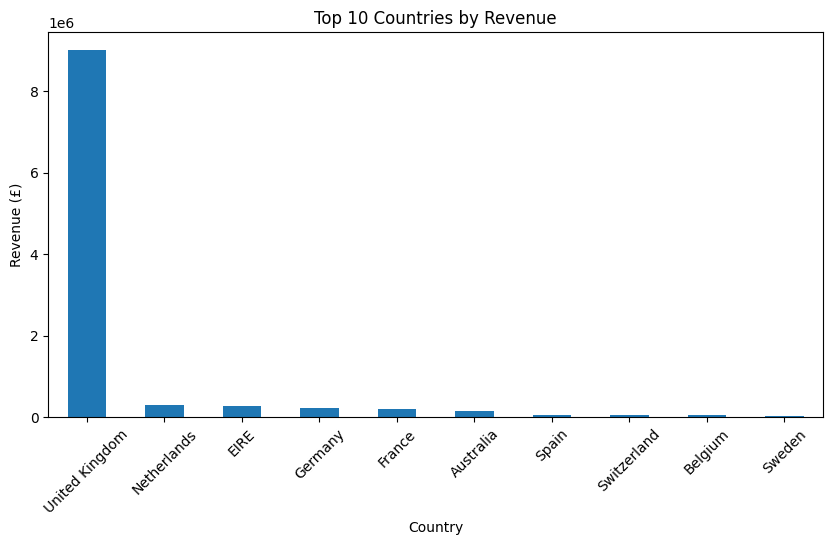

In [59]:
# Visualize the top 10 countries by revenue contribution

plt.figure(figsize=(10,5))

country_revenue.head(10).plot(
    kind="bar"
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)

plt.show()

### Business Insight

The United Kingdom generated the majority of revenue, contributing significantly more than any other country in the dataset.

The Netherlands, Ireland (EIRE), Germany, and France were among the next highest revenue-generating markets.

The results indicate that the business has a strong concentration of sales within the UK market, while other European countries represent additional opportunities for growth.

In [69]:
product_revenue = (
    df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

product_revenue.head(10)

Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POSTAGE                                78101.88
Manual                                 77752.82
RABBIT NIGHT LIGHT                     66870.03
Name: Revenue, dtype: float64

## 7. Product Performance Analysis

Products are ranked based on total revenue contribution to identify the highest revenue-generating items.

Before final product analysis, non-product transactions such as postage charges and manual adjustments are removed to ensure that the analysis represents actual product sales.

In [72]:
# Calculate revenue contribution by product description

product_revenue = (
    df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)


# Display the top 10 revenue-generating entries

product_revenue.head(10)

Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POSTAGE                                78101.88
Manual                                 77752.82
RABBIT NIGHT LIGHT                     66870.03
Name: Revenue, dtype: float64

### Result

The initial product revenue analysis includes entries such as postage charges and manual adjustments.

These records do not represent actual products sold, therefore they are removed before evaluating product performance.

In [75]:
# Remove non-product transactions such as postage charges and manual adjustments

product_df = df[
    ~df["Description"].str.contains(
        "POSTAGE|Manual",
        case=False,
        na=False
    )
]

In [76]:
# Recalculate product revenue after removing non-product transactions

product_revenue_clean = (
    product_df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)


# Display the top 10 products by revenue

product_revenue_clean.head(10)

Description
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
RABBIT NIGHT LIGHT                     66870.03
PAPER CHAIN KIT 50'S CHRISTMAS         64875.59
ASSORTED COLOUR BIRD ORNAMENT          58927.62
CHILLI LIGHTS                          54096.36
Name: Revenue, dtype: float64

### Business Insight

After removing non-product transactions such as postage charges and manual adjustments, the analysis highlights the products that contributed the highest revenue.

The **Regency Cakestand 3 Tier** and **Paper Craft, Little Birdie** were the top revenue-generating products, followed by items such as **White Hanging Heart T-Light Holder** and **Party Bunting**.

These products represent important contributors to overall sales performance and can be considered key products for further analysis and business decision-making.

In [ ]:
# Visualize the top 10 products by revenue

plt.figure(figsize=(12,6))

product_revenue_clean.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Product")

plt.show()

## 8. Overall Findings

The exploratory analysis provides insights into overall sales performance, customer activity, geographic contribution, and product performance.

Key findings include:
- The business generated over £10.6 million in revenue from nearly 20,000 orders.
- The average order value was £533.17.
- Revenue increased significantly during the final quarter of 2011, with November recording the highest monthly revenue.
- The United Kingdom was the dominant revenue-generating market.
- After removing non-product transactions, a small number of products contributed significantly to total revenue.